# Problem Formulation & Exploratory Data Analysis
Ahmet Doruk Güngör / 24018034
<br>
<br>

## 1| Problem Statement

-  I am trying to help Turkish game developers assess the performance of different genre and category combinations in the Turkish gaming market. This will be helpful in reducing potential losses from developing games that have a low chance of succeeding on the local market.

-  Within this project, I want to predict the likelyhood of a new game succeding depending on multiple factors.

-  This project is a classification task since it needs to determine if a game will be a success or not.

## 2| Dataset Description


### Sources:

[Original Steam Reviews Dataset](https://www.kaggle.com/datasets/kieranpoc/steam-reviews?resource=download) by KieranPO'C.
<br>
<br>
[Steam Game Genre and Categorie Dataset](https://huggingface.co/datasets/FronkonGames/steam-games-dataset) by Martin Bustos
<br>
<br>
(Gemini 3.1 Pro was used for learning new skills and graphical help)

### Creation of Dataset

#### 1- Removal of Non-Turkish Reviews:

In [5]:
import numpy
import scipy
import polars as pl


data = pl.scan_csv("all_reviews.csv")
 # Importing initial review dataset.

data = data.drop('recommendationid','author_steamid',
       'author_last_played', 'review',
       'timestamp_created', 'timestamp_updated','votes_up',
       'votes_funny', 'weighted_vote_score', 'steam_purchase',
       'received_for_free', 'written_during_early_access',
       'hidden_in_steam_china','comment_count','steam_china_location') # Dropped the unnecessary columns to reduce data size.

data = data.filter(pl.col("language").is_in(["turkish"])) # Dropped all non-Turkish review rows.

# Getting rid of rows with gameless authors (Incoherent Data).
data = data.with_columns(pl.col("author_num_games_owned").replace({0: None})) 
data = data.drop_nulls(pl.col("author_num_games_owned"))

# Writing resulting dataframe as a seperate file.
data.sink_csv("results.csv")

#### 2- Readying of Genre & Category Dataset:

In [6]:
data = pl.read_csv("results.csv") # Importing main dataset to only take game data present in main dataset.
genres = pl.read_parquet("train-00000-of-00001.parquet")
 # Importing dataset with genre & category data on each game.

#Dropping unnecessary data from genre & category dataset.
genres = genres.drop( 'tags','release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'dlc_count', 'detailed_description', 
                     'short_description', 
                     'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 
                     'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 
                     'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 
                     'median_playtime_2weeks', 'developers', 'publishers', 'screenshots', 'movies', 'packages')

# Turning present game titles to list for use in filtering.
List = pl.Series(data.select('game').unique()).to_list()

# Filtering genre & category dataset.
genres = genres.filter(pl.col("name").is_in(List))

# Saving resulting genre & category dataset as a parquet.
genres.write_parquet("Final_Genres.parquet")

#### 3- Fusing of Datasets + Turning Genres & Categories Into Encoding Columns

In [7]:
data = pl.read_csv("results.csv") # Reading main dataset.
genres = pl.read_parquet("Final_Genres.parquet") # Reading genre & category dataset.


# Converting all categort types to a list.
Categorie_List = pl.Series(genres.select(pl.col('categories')).explode(pl.col('categories')).unique()).to_list()
# Converting all genre types to a list.
Genre_List = pl.Series(genres.select(pl.col('genres')).explode(pl.col('genres')).unique()).to_list()
# Removing empty entries from genre list.
Genre_List = [tag for tag in Genre_List if tag is not None]
# Removing empty entries from category list.
Categorie_List = [tag for tag in Categorie_List if tag is not None]
# Making the columns containing game titles match in both datasets for joining.
genres = genres.rename({"name" : "game"})
# Joining datasets together.
data = data.join(genres,on="game",how="left")
# Adding individual genre columns and populating according to fused dataset.
dataEncoded = data.with_columns([pl.col("genres").list.contains(tag).alias(tag) for tag in Genre_List])
# Adding individual category columns and populating according to fused dataset.
dataEncoded = dataEncoded.with_columns([pl.col("categories").list.contains(tag1).alias(tag1) for tag1 in Categorie_List])
# Removing residual and obsolete columns from final dataset.
dataEncoded = dataEncoded.drop(["genres","categories","language","appID"])
# Saving final dataset as a csv file.
dataEncoded.write_csv("FinalResult.csv")

### Number of Rows & Columns

#### Rows: 2.351.006
#### Columns: 99

### Feature Descriptions

[appid]: Steam appid of reviewed game
<br><br>
[game]: Name of reviewed game
<br><br>
[author_num_games_owned]: Shows how many games user owns
<br><br>
[author_num_reviews]: Shows how many reviews user has written in total
<br><br>
[author_playtime_forever]: Shows user playtime on specific game
<br><br>
[author_playtime_last_two_weeks]: Shows user playtime in a two week window
<br><br>
[author_playtime_at_review]: Shows user playtime before writing review
<br><br>
[voted_up]: Shows if review is positive or negative
<br><br>
[genres & categories]: Genres & categories titles have shown in a one hot encoding format

### Limitations & Biases

-  Each game title has a different amount of reviews present in dataset.
-  Review amount differs from preferences of Turkish users.

## 3| Data Loading & Initial Inspection

In [1]:
import pandas as pd

data = pd.read_csv("FinalResult.csv",low_memory=False)
print(data.head())


   appid            game  author_num_games_owned  author_num_reviews  \
0     10  Counter-Strike                       7                   1   
1     10  Counter-Strike                      88                  39   
2     10  Counter-Strike                      41                   1   
3     10  Counter-Strike                      16                   3   
4     10  Counter-Strike                     127                  29   

   author_playtime_forever  author_playtime_last_two_weeks  \
0                     1440                            1440   
1                       11                               0   
2                    24396                              19   
3                      102                              20   
4                       34                              34   

   author_playtime_at_review  voted_up  360 Video  Audio Production  ...  \
0                       1313         1      False             False  ...   
1                         11         1    

In [9]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 2351005 entries, 0 to 2351004
Data columns (total 99 columns):
 #   Column                          Dtype 
---  ------                          ----- 
 0   appid                           int64 
 1   game                            str   
 2   author_num_games_owned          int64 
 3   author_num_reviews              int64 
 4   author_playtime_forever         int64 
 5   author_playtime_last_two_weeks  int64 
 6   author_playtime_at_review       int64 
 7   voted_up                        int64 
 8   360 Video                       object
 9   Audio Production                object
 10  Racing                          object
 11  Simulation                      object
 12  Episodic                        object
 13  Indie                           object
 14  Short                           object
 15  Education                       object
 16  Gore                            object
 17  Photo Editing                   object
 18  Sexual Conten

In [10]:
print(data.describe())

              appid  author_num_games_owned  author_num_reviews  \
count  2.351005e+06            2.351005e+06        2.351005e+06   
mean   5.312934e+05            1.998764e+02        4.051290e+01   
std    5.204207e+05            4.894206e+02        2.083388e+02   
min    1.000000e+01            1.000000e+00        1.000000e+00   
25%    2.118200e+05            4.100000e+01        3.000000e+00   
50%    3.461100e+05            8.800000e+01        8.000000e+00   
75%    7.823300e+05            1.850000e+02        2.100000e+01   
max    2.634420e+06            2.105300e+04        6.788000e+03   

       author_playtime_forever  author_playtime_last_two_weeks  \
count             2.351005e+06                    2.351005e+06   
mean              1.341183e+04                    6.037830e+01   
std               3.704765e+04                    3.995441e+02   
min               0.000000e+00                    0.000000e+00   
25%               4.310000e+02                    0.000000e+00   


###   Column                          Dtype <br>
---  ------                          ----- <br>
 0   appid:                          int64 <br>
 1   game:                           str   <br>
 2   author_num_games_owned:         int64 <br>
 3   author_num_reviews:             int64 <br>
 4   author_playtime_forever:        int64 <br>
 5   author_playtime_last_two_weeks: int64 <br>
 6   author_playtime_at_review:      int64 <br>
 7   voted_up:                       int64 <br>
 8   Accounting:                     object <br>
 9   Short:                           object <br>
 10  Free To Play:                   object <br>
 11  RPG:                          object <br>
 12  Nudity:                        object <br>
 13  Action:                       object <br>
 14  Simulation:                     object <br>
 15  Video Production:               object <br>
 16  Adventure:                      object <br>
 17  360 Video:                      object <br>
 18  Utilities:                      object <br>
 19  Episodic:                    object <br>
...<br>
 98  In-App Purchases                object <br>
dtypes: int64(7), object(91), str(1) <br>

## 4| Data Cleaning

### 1- Missing Values

In [11]:
data = pl.read_csv("FinalResult.csv") # Reading dataset.
data = data.filter(pl.col("Action").is_not_null()) # Removing entries lacking genre & category information
data.write_csv("FinalResult.csv") # Replacing old dataset with altered one.

### 2- Duplicate Rows

Cannot remove duplicates if they exist, this is caused by the nature of the dataset itself.

### 3- Incorrect Dtypes

In [12]:
# Converted object dtype colums in the dataset to boolean dtype because all values in tohose columns were boolean values.
data = pd.read_csv("FinalResult.csv",index_col=0)
data = data.convert_dtypes()
print(data.info())

<class 'pandas.DataFrame'>
Index: 1869608 entries, 10 to 997010
Data columns (total 98 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   game                            string 
 1   author_num_games_owned          Int64  
 2   author_num_reviews              Int64  
 3   author_playtime_forever         Int64  
 4   author_playtime_last_two_weeks  Int64  
 5   author_playtime_at_review       Int64  
 6   voted_up                        Int64  
 7   360 Video                       boolean
 8   Audio Production                boolean
 9   Racing                          boolean
 10  Simulation                      boolean
 11  Episodic                        boolean
 12  Indie                           boolean
 13  Short                           boolean
 14  Education                       boolean
 15  Gore                            boolean
 16  Photo Editing                   boolean
 17  Sexual Content                  boolean
 18

### 4- Outliers

I will not be doing outlier elimination based on game titles since that might effect ML classification result

#### A- author_num_games_owned

In [13]:
# I will be using the IQR method on all numerical columns.
# Calculating 1st and 3rd quantiles of data.
Q1 = data['author_num_games_owned'].quantile(0.25)
Q3 = data['author_num_games_owned'].quantile(0.75)
IQR = Q3 - Q1

data = data.query("(@Q1 - 1.5 * @IQR) <= author_num_games_owned <= (@Q3 + 1.5 * @IQR)") #Searching and saving data fitting criteria.
print(data.head())

                 game  author_num_games_owned  author_num_reviews  \
appid                                                               
10     Counter-Strike                       7                   1   
10     Counter-Strike                      88                  39   
10     Counter-Strike                      41                   1   
10     Counter-Strike                      16                   3   
10     Counter-Strike                     127                  29   

       author_playtime_forever  author_playtime_last_two_weeks  \
appid                                                            
10                        1440                            1440   
10                          11                               0   
10                       24396                              19   
10                         102                              20   
10                          34                              34   

       author_playtime_at_review  voted_up  360 Video

#### B- author_num_reviews

In [14]:
Q1 = data['author_num_reviews'].quantile(0.25)
Q3 = data['author_num_reviews'].quantile(0.75)
IQR = Q3 - Q1

data = data.query("(@Q1 - 1.5 * @IQR) <= author_num_reviews <= (@Q3 + 1.5 * @IQR)")
print(data.head())

                 game  author_num_games_owned  author_num_reviews  \
appid                                                               
10     Counter-Strike                       7                   1   
10     Counter-Strike                      41                   1   
10     Counter-Strike                      16                   3   
10     Counter-Strike                     127                  29   
10     Counter-Strike                      20                   2   

       author_playtime_forever  author_playtime_last_two_weeks  \
appid                                                            
10                        1440                            1440   
10                       24396                              19   
10                         102                              20   
10                          34                              34   
10                        2191                             403   

       author_playtime_at_review  voted_up  360 Video

#### C- author_playtime_forever

In [15]:
Q1 = data['author_playtime_forever'].quantile(0.25)
Q3 = data['author_playtime_forever'].quantile(0.75)
IQR = Q3 - Q1

data = data.query("(@Q1 - 1.5 * @IQR) <= author_playtime_forever <= (@Q3 + 1.5 * @IQR)")
print(data.head())

                 game  author_num_games_owned  author_num_reviews  \
appid                                                               
10     Counter-Strike                       7                   1   
10     Counter-Strike                      41                   1   
10     Counter-Strike                      16                   3   
10     Counter-Strike                     127                  29   
10     Counter-Strike                      20                   2   

       author_playtime_forever  author_playtime_last_two_weeks  \
appid                                                            
10                        1440                            1440   
10                       24396                              19   
10                         102                              20   
10                          34                              34   
10                        2191                             403   

       author_playtime_at_review  voted_up  360 Video

#### D- author_playtime_last_two_weeks

In [16]:
Above_Zero = data.query(" author_playtime_last_two_weeks > 0")
Q1 = Above_Zero['author_playtime_last_two_weeks'].quantile(0.25)
Q3 = Above_Zero['author_playtime_last_two_weeks'].quantile(0.75)
IQR = Q3 - Q1


data = data.query("author_playtime_last_two_weeks <= (@Q3 + 1.5 * @IQR)")
print(data.head())

                 game  author_num_games_owned  author_num_reviews  \
appid                                                               
10     Counter-Strike                      41                   1   
10     Counter-Strike                      16                   3   
10     Counter-Strike                     127                  29   
10     Counter-Strike                      20                   2   
10     Counter-Strike                      13                   1   

       author_playtime_forever  author_playtime_last_two_weeks  \
appid                                                            
10                       24396                              19   
10                         102                              20   
10                          34                              34   
10                        2191                             403   
10                        2838                             641   

       author_playtime_at_review  voted_up  360 Video

#### E- author_playtime_at_review

In [17]:
Q1 = data['author_playtime_at_review'].quantile(0.25)
Q3 = data['author_playtime_at_review'].quantile(0.75)
IQR = Q3 - Q1

data = data.query("(@Q1 - 1.5 * @IQR) <= author_playtime_at_review <= (@Q3 + 1.5 * @IQR)")
print(data.head())
data.to_csv("Final_Data.csv",index=False)

                 game  author_num_games_owned  author_num_reviews  \
appid                                                               
10     Counter-Strike                      16                   3   
10     Counter-Strike                     127                  29   
10     Counter-Strike                      20                   2   
10     Counter-Strike                      13                   1   
10     Counter-Strike                      27                   2   

       author_playtime_forever  author_playtime_last_two_weeks  \
appid                                                            
10                         102                              20   
10                          34                              34   
10                        2191                             403   
10                        2838                             641   
10                        2117                               0   

       author_playtime_at_review  voted_up  360 Video

## 5| Univariate Analysis

### Game Titles

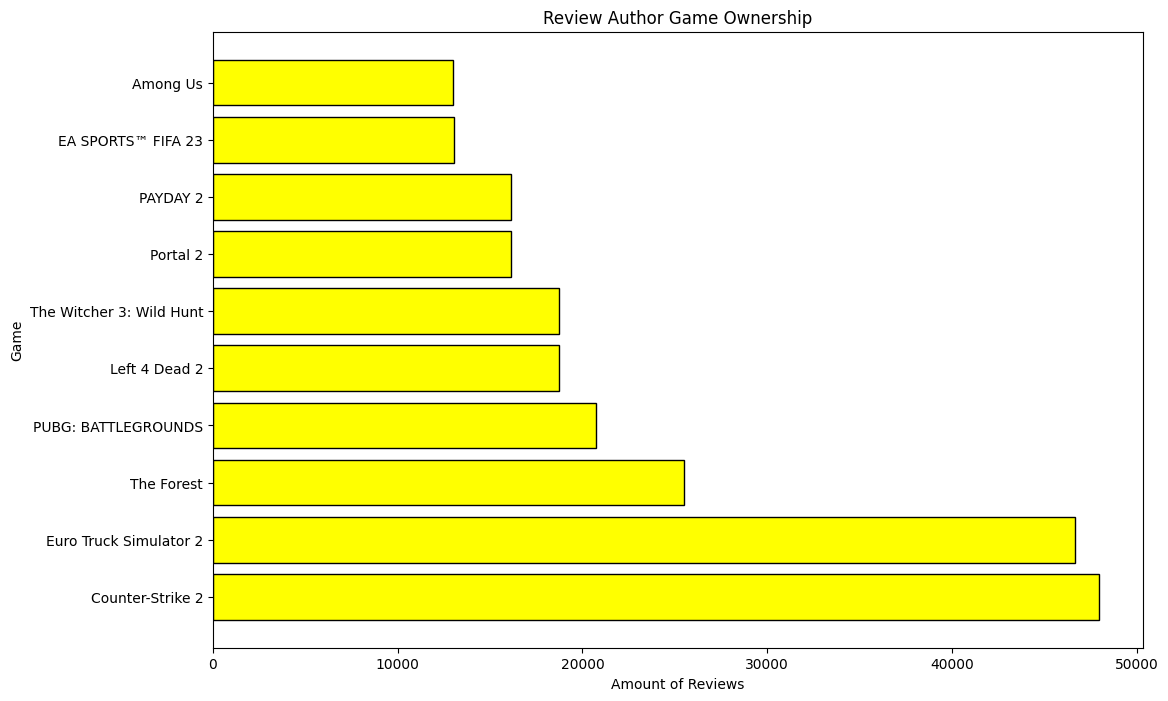

game
Counter-Strike 2    47943
Name: count, dtype: Int64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

top10_game_data = data["game"].value_counts().head(10) # Taking mention counts of game titles


top10_game_data = top10_game_data.sort_values(ascending=True) # Sorting values for better graph readability
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top10_game_data.index, top10_game_data.values, color='yellow', edgecolor='black') # Making bar graph

plt.title('Review Author Game Ownership')
plt.ylabel('Game')
plt.xlabel('Amount of Reviews')
ax.invert_yaxis()


plt.show()
print(top10_game_data.tail(1))


### author_num_games_owned

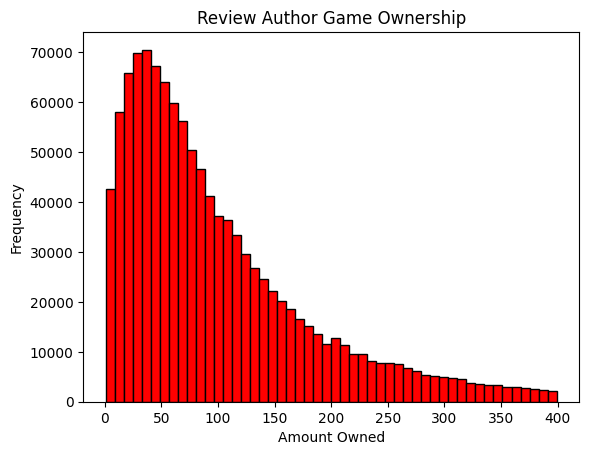

Mean:  99.03345872608102
Median:  75.0
Standart Deviation:  82.14111340622209
Skew:  1.3149846821734628


In [20]:
plt.hist(data['author_num_games_owned'], bins=50, color='red', edgecolor='black')

plt.title('Review Author Game Ownership')
plt.xlabel('Amount Owned')
plt.ylabel('Frequency')


plt.show()

print("Mean: ",data['author_num_games_owned'].mean())
print("Median: ",data['author_num_games_owned'].median())
print("Standart Deviation: ",data['author_num_games_owned'].std())
print("Skew: ",data['author_num_games_owned'].skew())

### author_num_reviews

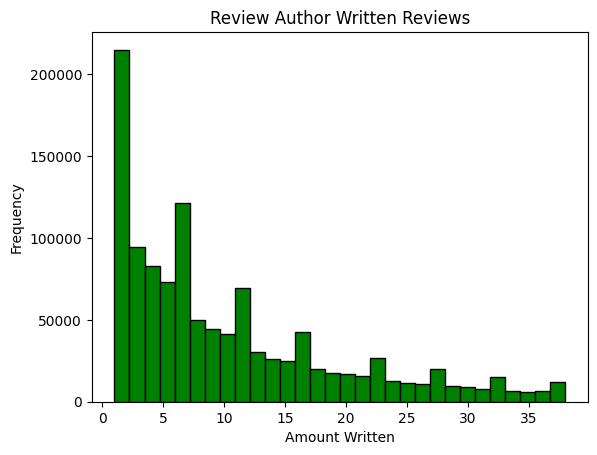

Mean:  10.276761586842445
Median:  7.0
Standart Deviation:  9.060107036776431
Skew:  1.1906330372777336


In [21]:
plt.hist(data['author_num_reviews'], bins=30, color='green', edgecolor='black')

plt.title('Review Author Written Reviews')
plt.xlabel('Amount Written')
plt.ylabel('Frequency')

plt.show()

print("Mean: ",data['author_num_reviews'].mean())
print("Median: ",data['author_num_reviews'].median())
print("Standart Deviation: ",data['author_num_reviews'].std())
print("Skew: ",data['author_num_reviews'].skew())


### author_playtime_forever

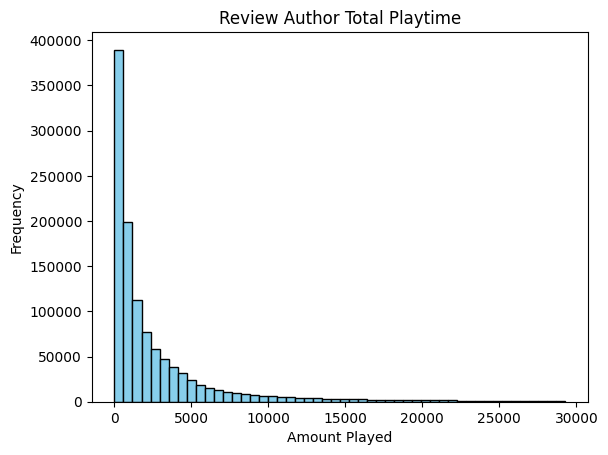

Mean:  2737.729955067355
Median:  1097.0
Standart Deviation:  4280.545029814819
Skew:  3.0429355217890084


In [22]:
plt.hist(data['author_playtime_forever'], bins=50, color='skyblue', edgecolor='black')

plt.title('Review Author Total Playtime')
plt.xlabel('Amount Played')
plt.ylabel('Frequency')


plt.show()

print("Mean: ",data['author_playtime_forever'].mean())
print("Median: ",data['author_playtime_forever'].median())
print("Standart Deviation: ",data['author_playtime_forever'].std())
print("Skew: ",data['author_playtime_forever'].skew())

### author_playtime_last_two_weeks

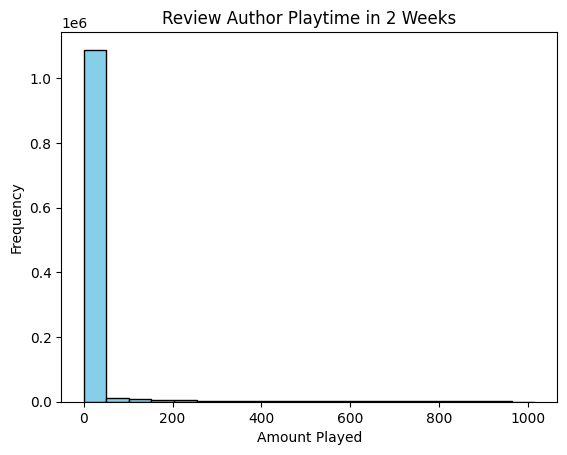

Mean:  14.428970373222494
Median:  0.0
Standart Deviation:  82.19185437034193
Skew:  7.558123393641859


In [23]:
plt.hist(data['author_playtime_last_two_weeks'], bins=20, color='skyblue', edgecolor='black')

plt.title('Review Author Playtime in 2 Weeks')
plt.xlabel('Amount Played')
plt.ylabel('Frequency')


plt.show()

print("Mean: ",data['author_playtime_last_two_weeks'].mean())
print("Median: ",data['author_playtime_last_two_weeks'].median())
print("Standart Deviation: ",data['author_playtime_last_two_weeks'].std())
print("Skew: ",data['author_playtime_last_two_weeks'].skew())

### author_playtime_at_review

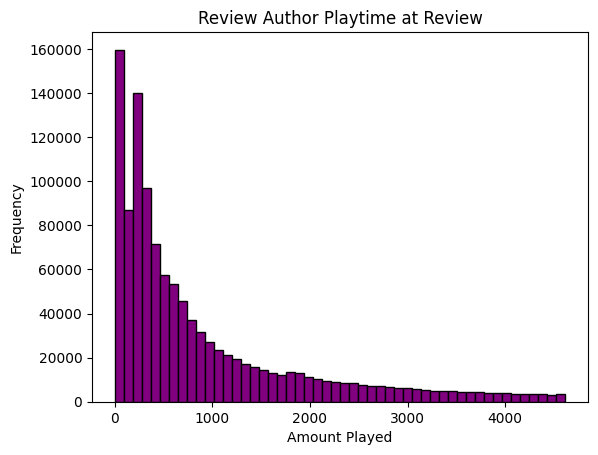

Mean:  900.1758521459
Median:  484.0
Standart Deviation:  1023.5280004049865
Skew:  1.6544967150228376


In [24]:
plt.hist(data['author_playtime_at_review'], bins=50, color='purple', edgecolor='black')

plt.title('Review Author Playtime at Review')
plt.xlabel('Amount Played')
plt.ylabel('Frequency')


plt.show()

print("Mean: ",data['author_playtime_at_review'].mean())
print("Median: ",data['author_playtime_at_review'].median())
print("Standart Deviation: ",data['author_playtime_at_review'].std())
print("Skew: ",data['author_playtime_at_review'].skew())

## 6| Bivariate & Multivariate Analysis

### Multivariate Heatmap

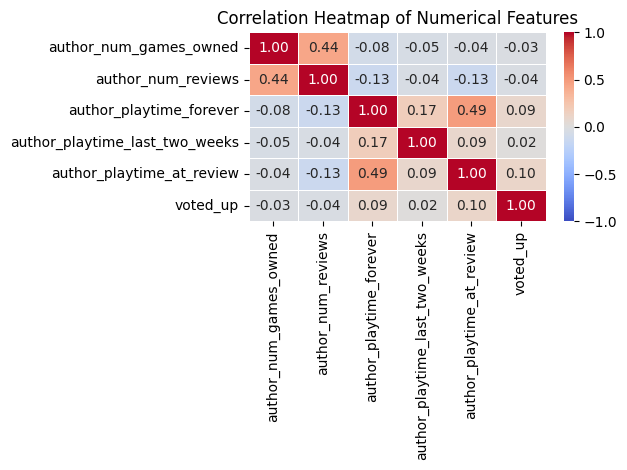

In [25]:
numeric_data = data.select_dtypes(include=['number']) # I made sure that it only uses numerical columns
corr_matrix = numeric_data.corr() # Making correlation matrix.
sns.heatmap(
    corr_matrix, 
    annot=True,        
    cmap='coolwarm',   
    fmt=".2f",         
    vmin=-1,           
    vmax=1,            
    linewidths=0.5     
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

## 7| Key Findings & Next Steps

-  Majority of authors played less 200 hours in last 2 weeks
-  There is an interesting pattern present on total reviews writen by authors
-  Majority of authors that write rewies have played the game in question less than 5000 hours
<br>
<br>
-  There is an obvious relationship betwwen amount of games owned and amount of reviews written
-  Currrently determining a target is difficult, there are currently a lot of target variables since data was one hot encoded


## 8| Github Repository

[Github Repository](https://github.com/memoryVoid1/Introduction_To_Machine_Learning_Project/tree/main)<br> <br>
[My Github Page](https://github.com/memoryVoid1)